## **Image Classification Using Pre-trained Models** 

___

**Instructions** <br>
- Look for a suitable **image classification dataset**, or create your own **custom dataset** following the procedure demonstrated during the previous class discussion.
- Curate and organize the dataset appropriately for an image classification task.
- Create a custom PyTorch Dataset class to load and process the curated dataset.
- Create appropriate DataLoader objects for loading the dataset in batches for model evaluation.
- **Perform model inference** using different trained/pre-trained models available from torchvision.models.
- Evaluate and compare up to **five (5) different models** using appropriate performance metrics, such as **accuracy, precision, recall, and F1-score**.
- Present the comparison of the models clearly using a **table and/or appropriate visualizations.**
- Write a **short analysis and conclusion** discussing the results. Explain possible reasons why the models produced different levels of performance, considering factors such as model architecture, model complexity, input requirements, and suitability for the selected dataset.

In [1]:
import os
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from torchvision import models

import cv2
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


#### **Dataset Preparation and Class Label Mapping**

In [2]:
root = './dataset'

data_dict = {'X': [], 'y': []}

for cls in sorted(os.listdir(root)):
    cls_path = os.path.join(root, cls)
    if not os.path.isdir(cls_path):
        continue
    for img in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img)
        data_dict['X'].append(img_path)
        data_dict['y'].append(int(cls))

df = pd.DataFrame(data_dict)
print('Total images:', len(df))
df['y'].value_counts()


Total images: 25


y
931    5
932    5
934    5
963    5
965    5
Name: count, dtype: int64

In [3]:
ref_categories = models.ResNet50_Weights.DEFAULT.meta['categories']
class_names = {idx: ref_categories[idx] for idx in sorted(df['y'].unique())}
class_names

{931: 'bagel', 932: 'pretzel', 934: 'hotdog', 963: 'pizza', 965: 'burrito'}

#### **Dataset Summary**
The dataset contains five ImageNet-1K classes: bagel, pretzel, hotdog, pizza, and burrito. Each class contains an equal number of images, with the images organized into class-specific folders using their corresponding ImageNet class indices. The dataset was curated to include varied image examples within each class, including differences in visual appearance and image composition. This allows the pretrained torchvision models to be evaluated directly on the selected classes without additional fine-tuning.

In [4]:
# Dataset summary
summary_df = (
    df['y']
    .value_counts()
    .sort_index()
    .rename_axis('Class ID')
    .reset_index(name='Number of Images')
)

summary_df['Class'] = summary_df['Class ID'].map(class_names)

summary_df = summary_df[['Class ID', 'Class', 'Number of Images']]

summary_df

,Class ID,Class,Number of Images
0,931,bagel,5
1,932,pretzel,5
2,934,hotdog,5
3,963,pizza,5
4,965,burrito,5


#### **Sample Images from the Dataset**
The following grid presents representative images from each of the five selected classes. The samples provide a visual overview of the curated dataset and show the variety of image appearances within each class before the images are processed by the custom PyTorch Dataset and pretrained models.


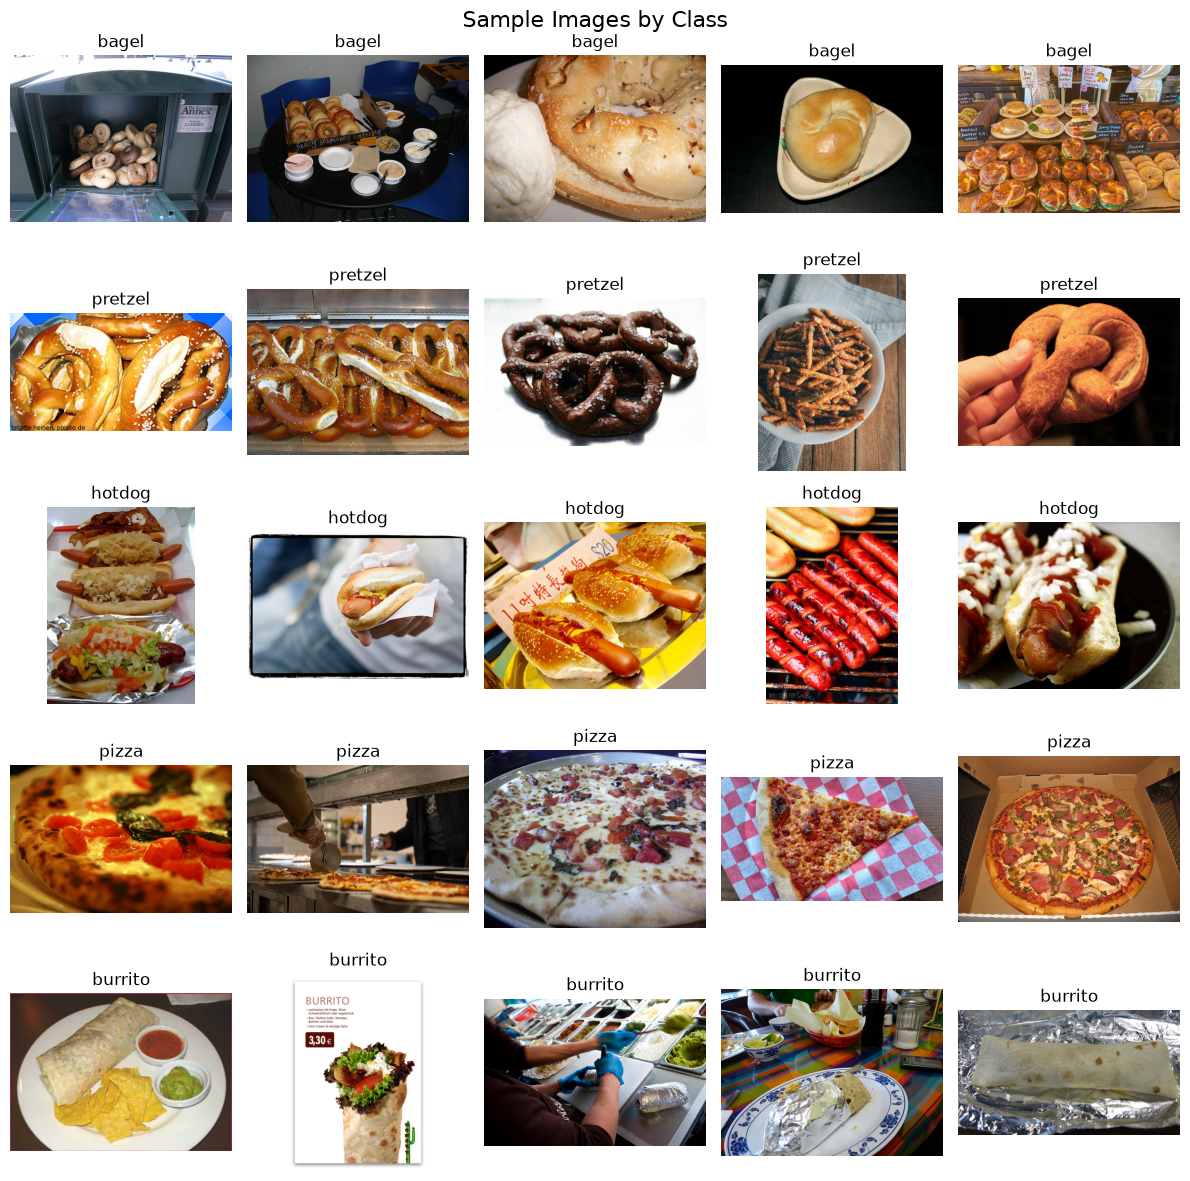

In [5]:
# Display sample images from each class

fig, axes = plt.subplots(
    nrows=len(class_names),
    ncols=5,
    figsize=(12, 12)
)

for row, class_id in enumerate(sorted(class_names.keys())):
    class_images = df[df['y'] == class_id]['X'].tolist()[:5]

    for col in range(5):
        ax = axes[row, col]

        if col < len(class_images):
            img = cv2.imread(class_images[col])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax.imshow(img)
            ax.set_title(class_names[class_id])
        
        ax.axis('off')

plt.suptitle('Sample Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

#### **Custom Dataset and Image Preprocessing**
This code defines a custom PyTorch dataset that loads images and their labels, converts the images to RGB format, and applies the specified preprocessing transformations before returning them as tensors.

In [6]:
class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        img_bgr = cv2.imread(self.data_dict['X'][idx])

        if img_bgr is None:
            raise ValueError(f"Could not read image: {self.data_dict['X'][idx]}")

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        y = torch.tensor(self.data_dict['y'][idx], dtype=torch.long)

        # Convert NumPy array to PIL Image before torchvision preprocessing
        img_pil = transforms.ToPILImage()(img_rgb)

        if self.transforms:
            x = self.transforms(img_pil)
        else:
            x = transforms.ToTensor()(img_pil)

        return x, y

    def __len__(self):
        return len(self.data_dict['X'])

#### **Models to Compare**<br>

Five pretrained `torchvision` models spanning a range of architecture
families, depths, and parameter counts are compared: ResNet50,
ResNet18, VGG16, EfficientNet-B0, and MobileNetV3-Large.
- **ResNet50** – A deeper residual network used to evaluate the performance of a higher-capacity model.
- **ResNet18** – A smaller and shallower ResNet used to compare the effect of network depth.
- **VGG16** – A traditional, larger CNN architecture used to compare performance with a more parameter-heavy model.
- **EfficientNet-B0** – A compact architecture designed to balance accuracy and computational efficiency.
- **MobileNetV3-Large** – A lightweight architecture designed for faster and more resource-efficient inference.

These models were selected to compare the trade-offs between classification performance, model complexity, and inference time. Each model uses its official pretrained weights from torchvision.models and is evaluated without additional training or fine-tuning to maintain consistent evaluation conditions.

In [7]:
MODEL_CONFIGS = [
    ('ResNet50',           models.resnet50,             models.ResNet50_Weights.DEFAULT),
    ('ResNet18',           models.resnet18,             models.ResNet18_Weights.DEFAULT),
    ('VGG16',              models.vgg16,                models.VGG16_Weights.DEFAULT),
    ('EfficientNet_B0',    models.efficientnet_b0,      models.EfficientNet_B0_Weights.DEFAULT),
    ('MobileNetV3_Large',  models.mobilenet_v3_large,   models.MobileNet_V3_Large_Weights.DEFAULT),
]

In [8]:
results = []
all_preds = {}

BATCH_SIZE = 8
target_labels = sorted(class_names.keys())

for model_name, model_fn, weights in MODEL_CONFIGS:

    # Model-specific preprocessing
    preprocess = weights.transforms()

    # Dataset and DataLoader
    dataset = CustomDataset(data_dict, preprocess)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Load pretrained model
    model = model_fn(weights=weights).to(device)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters())

    y_true = []
    y_pred = []

    start = time.time()
    with torch.no_grad():
        for x_batch, y_batch in tqdm(loader, desc=model_name, leave=True):
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(y_batch.numpy().tolist())
    elapsed = time.time() - start

    # Evaluation metrics
    acc = accuracy_score(
        y_true,
        y_pred
    )

    prec = precision_score(
        y_true,
        y_pred,
        labels=target_labels,
        average='macro',
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        labels=target_labels,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        labels=target_labels,
        average='macro',
        zero_division=0
    )

    # Correct predictions
    correct = sum(
        true == pred
        for true, pred in zip(y_true, y_pred)
    )

    total = len(y_true)

    # Store results
    results.append({
        'Model': model_name,
        'Correct / Total': f'{correct} / {total}',
        'Params (M)': round(n_params / 1e6, 1),
        'Accuracy': round(acc, 3),
        'Precision (macro)': round(prec, 3),
        'Recall (macro)': round(rec, 3),
        'F1 (macro)': round(f1, 3),
        'Inference time (s)': round(elapsed, 3)
    })

    # Save predictions for later visualizations
    all_preds[model_name] = (
        y_true,
        y_pred
    )

    # Free memory
    del model

    if device.type == 'cuda':
        torch.cuda.empty_cache()

ResNet50:   0%|          | 0/4 [00:00<?, ?it/s]

ResNet18:   0%|          | 0/4 [00:00<?, ?it/s]

VGG16:   0%|          | 0/4 [00:00<?, ?it/s]

EfficientNet_B0:   0%|          | 0/4 [00:00<?, ?it/s]

MobileNetV3_Large:   0%|          | 0/4 [00:00<?, ?it/s]

#### **Results Across All Models**

In [9]:
# Results table
results_df = (
    pd.DataFrame(results)
    .sort_values(
        'Accuracy',
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Correct / Total,Params (M),Accuracy,Precision (macro),Recall (macro),F1 (macro),Inference time (s)
0,ResNet50,24 / 25,25.6,0.96,1.0,0.96,0.978,3.005
1,EfficientNet_B0,24 / 25,5.3,0.96,1.0,0.96,0.978,1.502
2,ResNet18,22 / 25,11.7,0.88,1.0,0.88,0.933,1.910
3,VGG16,21 / 25,138.4,0.84,1.0,0.84,0.911,6.968
4,MobileNetV3_Large,21 / 25,5.5,0.84,1.0,0.84,0.906,1.076


> The results show that **ResNet50** and **EfficientNet-B0** achieved the highest accuracy, correctly classifying 24 out of 25 samples with an accuracy of 0.96. Despite their similar performance, EfficientNet-B0 is more lightweight, with only 5.3 million parameters and an inference time of 1.502 seconds, compared with ResNet50's 25.6 million parameters and 3.005 seconds. ResNet18 correctly classified 22 out of 25 samples, while VGG16 and MobileNetV3-Large correctly classified 21 out of 25. VGG16 had the highest number of parameters (138.4M) and the longest inference time (6.968s), while MobileNetV3-Large had the shortest inference time (1.076s). Overall, the results show that model size and inference time vary considerably, while higher complexity does not necessarily lead to higher classification accuracy.

#### **Model Comparison Across Evaluation Metrics**

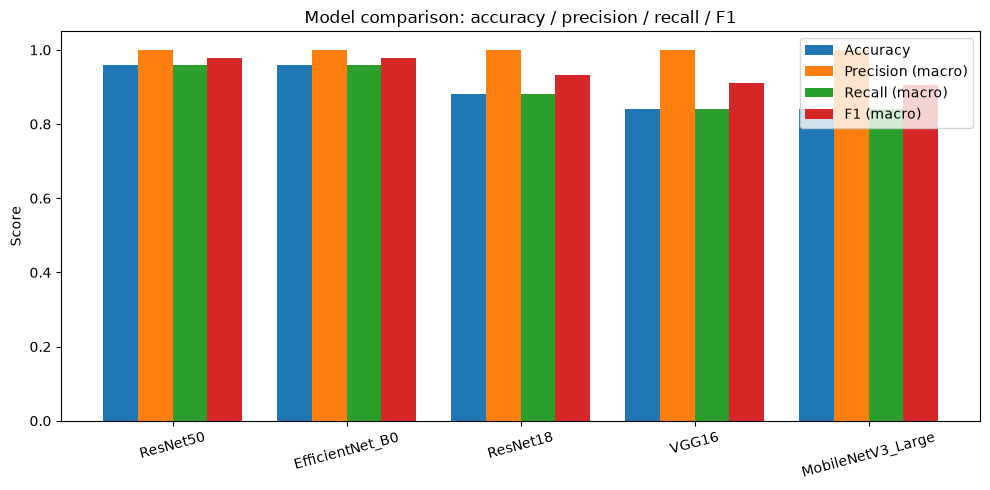

In [10]:
metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model comparison: accuracy / precision / recall / F1')
ax.legend()
plt.tight_layout()
plt.show()


>Precision (orange) sits at a flat 1.0 across every single model, the tallest, most uniform bar in the chart. This visually confirms the key finding from your metrics: no model ever confused one of the five target classes for another. Accuracy (blue) and Recall (green) are essentially the same height for every model, with precision fixed at 1.0 and equal class sizes, recall and accuracy converge to nearly the same value. F1 (red) consistently lands between recall and precision, since F1 is their harmonic mean. The chart cleanly splits into two tiers: ResNet50 and EfficientNet-B0 with the tallest accuracy/recall/F1 bars (~0.96–0.98), and ResNet18, VGG16, and MobileNetV3-Large trailing with visibly shorter bars (~0.84–0.93), precision is the one metric that doesn't distinguish the tiers at all.

#### **Model Performance Across Evaluation Metrics**

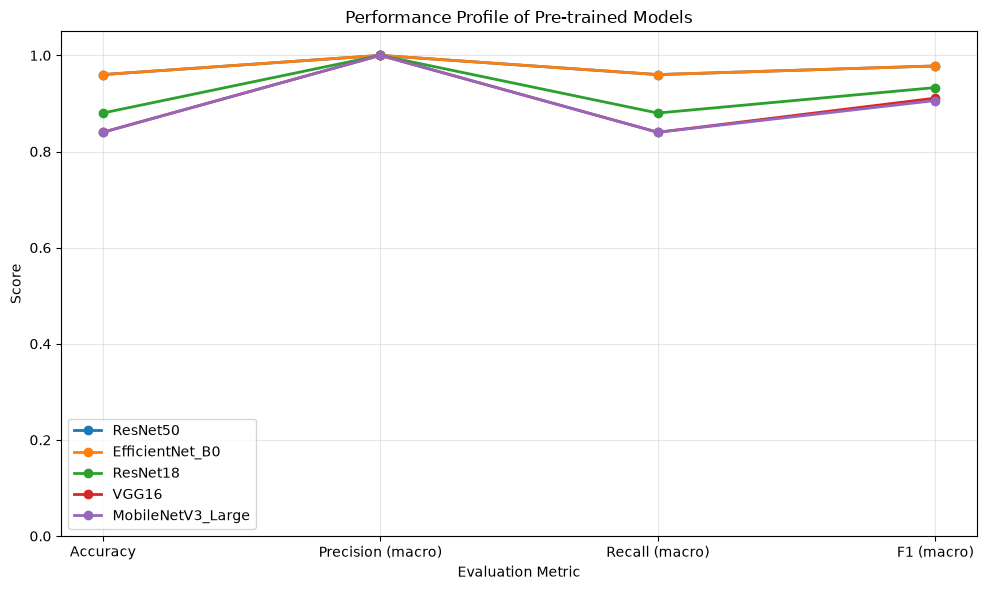

In [11]:
metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']

plt.figure(figsize=(10, 6))

for model in results_df['Model']:
    values = results_df.loc[
        results_df['Model'] == model,
        metrics
    ].values.flatten()

    plt.plot(
        metrics,
        values,
        marker='o',
        linewidth=2,
        label=model
    )

plt.ylim(0, 1.05)
plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.title('Performance Profile of Pre-trained Models')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

>The performance profiles show that some models achieved very similar results, causing their lines to closely overlap. ResNet50 and EfficientNet-B0 follow nearly identical performance patterns, while VGG16 and MobileNetV3-Large also show closely aligned results, particularly at the F1-score. This overlap reflects the similarity of their actual performance rather than a visualization issue. All models reached a macro-precision of 1.00, creating a common peak in the chart. However, ResNet18, VGG16, and MobileNetV3-Large show a noticeable drop in recall before recovering slightly at the F1-score. This indicates that recall is the main metric contributing to the differences in overall model performance, while precision remains consistently high across all models.

#### **Classification Results Matrix**

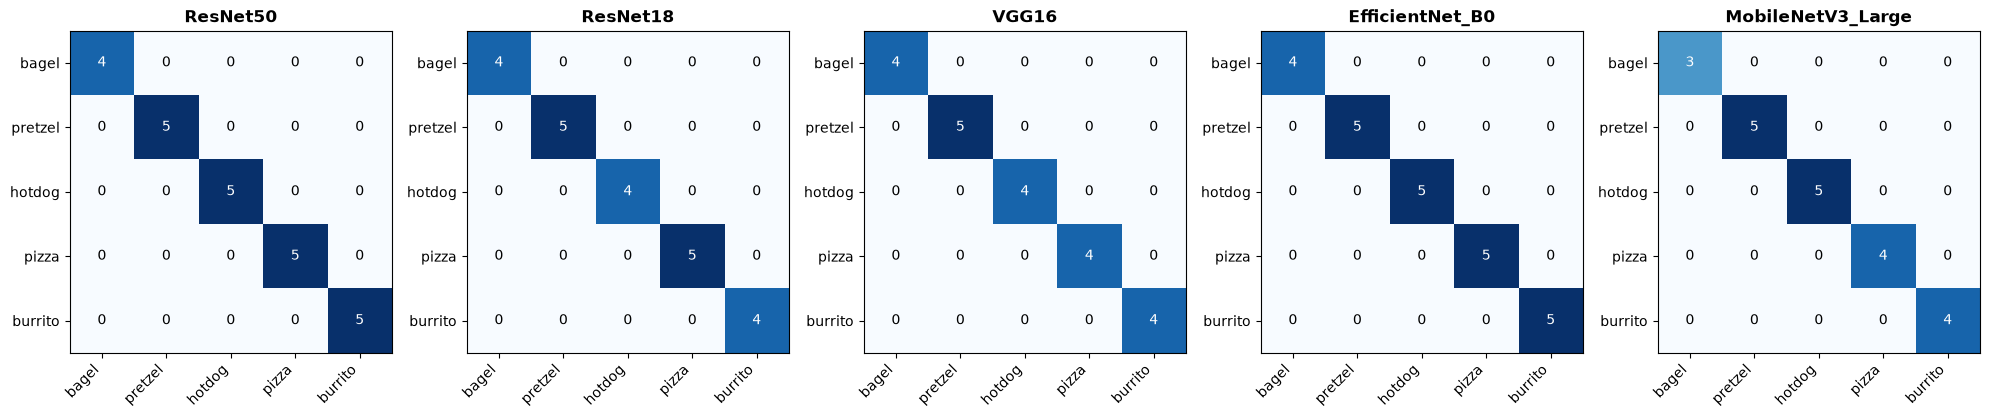

In [12]:
class_ids = sorted(class_names.keys())
labels = [class_names[c] for c in class_ids]

fig, axes = plt.subplots(1, len(MODEL_CONFIGS), figsize=(4 * len(MODEL_CONFIGS), 4))

for ax, (model_name, _, _) in zip(axes, MODEL_CONFIGS):
    y_true, y_pred = all_preds[model_name]
    cm = confusion_matrix(y_true, y_pred, labels=class_ids)

    ax.imshow(cm, cmap='Blues')
    ax.set_title(model_name, fontweight='bold')

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)

    # Annotate each cell with its raw count
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

>The confusion matrices show that most samples were correctly classified, with predictions concentrated along the diagonal. ResNet50 and EfficientNet-B0 produced the fewest misclassifications, while ResNet18 and VGG16 had additional missed samples across several classes. MobileNetV3-Large showed the most noticeable errors, particularly in the bagel class, where only 3 out of 5 samples were correctly classified. Some rows contain fewer than five predictions because misclassified samples assigned to classes outside the five target categories are not displayed in the matrices.

#### **Incorrect Prediction Analysis**

In [13]:
# Incorrect Prediction Analysis

imagenet_categories = (
    models.ResNet50_Weights.DEFAULT.meta['categories']
)

for model_name, (y_true, y_pred) in all_preds.items():
    print(f'\n--- {model_name} ---')
    found_error = False
    for true_label, pred_label in zip(
        y_true,
        y_pred
    ):
        if true_label != pred_label:
            found_error = True
            true_name = class_names[true_label]
            pred_name = imagenet_categories[pred_label]
            print(
                f'Actual: {true_name} '
                f'→ Predicted: {pred_name}'
            )

    if not found_error:
        print('No incorrect predictions.')


--- ResNet50 ---
Actual: bagel → Predicted: bakery

--- ResNet18 ---
Actual: bagel → Predicted: bakery
Actual: hotdog → Predicted: grocery store
Actual: burrito → Predicted: water bottle

--- VGG16 ---
Actual: bagel → Predicted: bakery
Actual: hotdog → Predicted: crayfish
Actual: pizza → Predicted: bakery
Actual: burrito → Predicted: paintbrush

--- EfficientNet_B0 ---
Actual: bagel → Predicted: bakery

--- MobileNetV3_Large ---
Actual: bagel → Predicted: French loaf
Actual: bagel → Predicted: bakery
Actual: pizza → Predicted: spatula
Actual: burrito → Predicted: water bottle


>The prediction results show that the models generally struggled with fine-grained food recognition, particularly for bagel, hotdog, pizza, and burrito images. A notable pattern was the repeated misclassification of bagel as “bakery” across ResNet50, ResNet18, VGG16, and EfficientNet-B0. This suggests that the models may have been influenced by contextual or background features associated with a bakery rather than focusing exclusively on the bagel itself. MobileNetV3-Large also predicted some bagel images as “French loaf,” which is visually and semantically closer to the actual class because both are bread products. Other errors were less semantically related, such as burrito being classified as “water bottle” or “paintbrush,” and pizza being classified as “spatula.” These results suggest that the models can sometimes rely on visual characteristics such as shape, color, texture, or surrounding objects when the target food is difficult to distinguish. Overall, the errors demonstrate that pretrained ImageNet models may recognize general visual patterns successfully while still having difficulty with fine-grained distinctions between visually similar or contextually related classes.


#### **Model Complexity and Inference Time**

This comparison examines the relationship between the number of trainable parameters and inference time. It provides an additional view of model computational efficiency alongside classification performance.


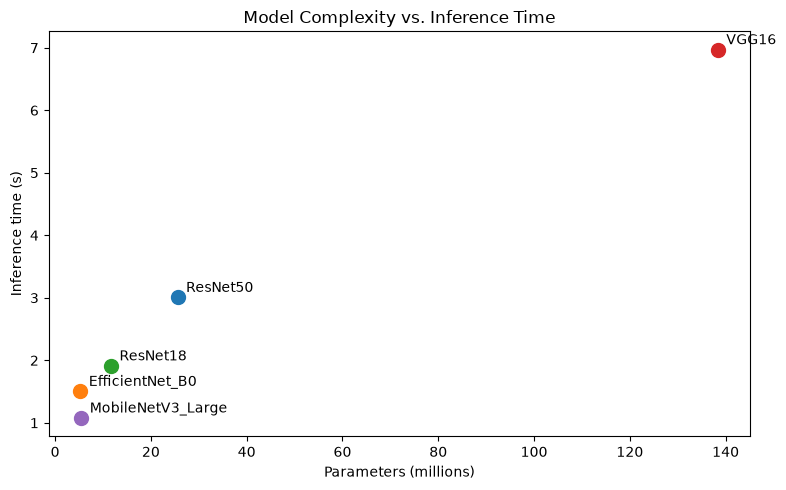

In [14]:
# Model Complexity vs. Inference Time
fig, ax = plt.subplots(figsize=(8, 5))

for _, row in results_df.iterrows():
    ax.scatter(row['Params (M)'], row['Inference time (s)'], s=100)
    ax.annotate(row['Model'], (row['Params (M)'], row['Inference time (s)']),
                textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('Parameters (millions)')
ax.set_ylabel('Inference time (s)')
ax.set_title('Model Complexity vs. Inference Time')
plt.tight_layout()
plt.show()

>The chart shows a clear relationship between model complexity and inference time. VGG16 has by far the largest number of parameters (approximately 138 million) and also requires the longest inference time at nearly 7 seconds. In comparison, MobileNetV3-Large has the fewest parameters (around 5 million) and the shortest inference time at approximately 1.1 seconds. EfficientNet-B0 and ResNet18 also have relatively low parameter counts and inference times of about 1.5 and 1.9 seconds, respectively, while ResNet50 requires around 3 seconds with approximately 26 million parameters. Overall, the results indicate that models with greater parameter counts generally require more time for inference, while more lightweight architectures can provide faster processing with substantially lower model complexity.

#### **Conclusion**
The five pretrained models were able to classify the selected food images with varying levels of performance. ResNet50 and EfficientNet-B0 achieved the highest accuracy at 96%, while EfficientNet-B0 required substantially fewer parameters and less inference time. The results also show that a larger or more complex model does not always produce better performance. Misclassifications occurred mainly when the images contained visual or contextual features that differed from the target class. Overall, the comparison demonstrates the trade-off between classification performance, model complexity, and computational efficiency when using pretrained models.

Overall, the five pretrained models were able to classify the selected food images without additional training. ResNet50 and EfficientNet-B0 achieved the highest accuracy, while EfficientNet-B0 required substantially fewer parameters and less inference time than ResNet50. The results also show that larger models do not necessarily provide better performance, as model architecture and efficiency can affect the results. However, the evaluation was performed on only 25 images, so the results should be interpreted as a small-scale comparison rather than a general measure of model performance.